# Top2Vec - Vibecoding Tweet Topic Modeling

Notebook ini menjalankan Top2Vec pada dataset tweet vibecoding yang sama dengan FASTopic
& BERTopic (`preprocessed_new_vibe_coding_tweets.csv`) supaya hasilnya bisa dibandingkan apple-to-apple.

**Pipeline Top2Vec:** sentence/document embedding (MiniLM) -> UMAP -> HDBSCAN -> topic vector
adalah centroid cluster, lalu top words dipilih dari kata-kata terdekat (cosine) ke topic vector
di shared embedding space. Berbeda dengan BERTopic yang pakai c-TF-IDF, Top2Vec memilih top words
murni dari semantic distance di embedding space.

In [7]:
import pandas as pd
import numpy as np
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dataset SAMA persis dengan FASTopic & BERTopic notebook.
df_preprocessed = pd.read_csv(r"../preprocessed_new_vibe_coding_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 19049


,full_text_translated,image_url
0,vibes capital meets vibecoding greatest econom...,NaN
1,attest vibecoding hella fun borderline like do...,NaN
2,built app ideas spare time one internal tool u...,NaN
3,karpathy discovered secret engineer vibecoding,NaN
4,assisted vibecoding works great data analysis ...,NaN


In [8]:
docs = df_preprocessed['full_text_translated'].fillna('').tolist()
images = df_preprocessed['image_url'].tolist()
for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# Top2Vec butuh dokumen non-kosong dan minimal beberapa token. Filter defensif:
docs_filtered = [d for d in docs if isinstance(d, str) and len(d.split()) >= 3]
print(f"Docs setelah filter (>=3 token): {len(docs_filtered)}")
docs = docs_filtered

Docs setelah filter (>=3 token): 19049


## Evaluation Setup

Memakai `topmost.Preprocess` HANYA untuk membangun reference corpus + vocabulary yang
identik dengan FASTopic & BERTopic. Penting untuk fairness skor coherence antar model.

Tiga metric yang dipakai:
- **C_v** — PMI berbasis sliding window + cosine similarity. Range ~0-1.
- **C_npmi** — Normalized PMI. Range ~[-1, 1] (~0.05-0.20 untuk tweet).
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0-1.

In [9]:
from topmost import Preprocess
from topmost.eva import _coherence, _diversity

# Stopwords config IDENTIK dengan FASTopic & BERTopic notebook.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe"]
generic_stopwords = [
    "code", "coding", "app", "apps", "build", "building", "built",
    "like", "get", "got", "one", "use", "using", "used", "people",
    "time", "new", "make", "made", "really", "going", "would", "could",
    "even", "much", "still", "also", "thing", "things", "want",
    "way", "ways", "first", "every", "see", "know", "think",
    "good", "great", "right", "now", "today", "yeah", "lot",
]

shared_preprocess = Preprocess(
    vocab_size=5000,
    stopwords=domain_stopwords + generic_stopwords,
    min_doc_count=15,
    max_doc_freq=0.4,
    min_term=5,
)

prep_result = shared_preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
ref_vocab_set = set(ref_vocab)
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

loading train texts:   0%|          | 0/19049 [00:00<?, ?it/s]

parsing texts: 100%|██████████| 15724/15724 [00:00<00:00, 59120.94it/s]
c:\Users\Allen\Documents\Python Env\environments\derp_learning\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2026-04-26 08:16:29,905 - TopMost - Real vocab size: 2573
2026-04-26 08:16:29,905 - TopMost - Real training size: 15724 	 avg length: 11.144


Reference corpus: 15724 docs | vocab: 2573 terms


In [10]:
def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity."""
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}


def top2vec_top_words(model, reduced=False, topn=15, vocab_filter=None):
    """Ekstrak top words per topic dari Top2Vec.

    vocab_filter: optional set/list -- bila diberikan, kata yang tidak ada di vocab ini di-skip.
    Berguna supaya top words berasal dari shared vocab dengan FASTopic/BERTopic.
    """
    topic_words, word_scores, topic_nums = model.get_topics(reduced=reduced)
    out = []
    for words in topic_words:
        if vocab_filter is not None:
            filtered = [w for w in words if w in vocab_filter]
        else:
            filtered = list(words)
        out.append(' '.join(filtered[:topn]))
    return out

## Top2Vec Config Rationale

- **`embedding_model='all-MiniLM-L6-v2'`**: SAMA dengan FASTopic & BERTopic untuk fairness.
- **`min_count=15`**: kata dengan freq < 15 dibuang dari vocabulary internal Top2Vec.
  Selaras dengan `min_doc_count=15` di FASTopic.
- **`speed='learn'`**: kompromi antara `fast-learn` (tidak akurat) dan `deep-learn` (lambat).
  Tidak terlalu relevan karena kita pakai pretrained transformer (bukan train doc2vec).
- **`workers=4`**: parallelism. Naikkan kalau mesin punya banyak core.
- **K-sweep via `hierarchical_topic_reduction`**: Top2Vec auto-discover jumlah topik via HDBSCAN.
  Untuk membandingkan dengan K tertentu, kita reduce hierarchically ke target K.

In [11]:
from top2vec import Top2Vec
import logging

logging.getLogger("top2vec").setLevel(logging.WARNING)

# Top2Vec di-train SEKALI dengan param default. Untuk K-sweep, kita reduce hierarchically.
# Training ~2-5 menit pada 16k tweets (bottleneck: UMAP + HDBSCAN).
np.random.seed(SEED)

base_model = Top2Vec(
    documents=docs,
    embedding_model="all-MiniLM-L6-v2",
    min_count=15,
    speed="learn",
    workers=4,
    verbose=True,
)

n_topics_raw = base_model.get_num_topics()
print(f"\nTop2Vec mendiskoveri {n_topics_raw} topik mentah (sebelum reduction).")

2026-04-26 08:16:29,942 - top2vec - INFO - Pre-processing documents for training


2026-04-26 08:16:30,427 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7283.74it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-26 08:16:36,743 - top2vec - INFO - Creating joint document/word embedding
2026-04-26 08:16:42,871 - top2vec - INFO - Creating lower dimension embedding of documents
2026-04-26 08:16:44,832 - top2vec - INFO - Finding dense areas of documents
2026-04-26 08:16:46,327 - top2vec - INFO - Finding topics



Top2Vec mendiskoveri 2 topik mentah (sebelum reduction).


## K-Sweep via Hierarchical Topic Reduction

Top2Vec mendiskoveri jumlah topik awal otomatis (sering banyak: 30-100+ untuk dataset segini).
`hierarchical_topic_reduction(num_topics=K)` menggabungkan topik termirip secara iteratif sampai
tersisa K topik. Kita evaluasi tiap level reduksi.

Kalau jumlah topik mentah lebih kecil dari max(K_VALUES), nilai K yang lebih besar dari itu
akan di-skip otomatis.

In [12]:
K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

# Top2Vec.hierarchical_topic_reduction butuh num_topics < jumlah topik saat ini.
# Kalau Top2Vec hanya menemukan sedikit topik mentah (mis. 2), seluruh K di atasnya
# akan di-skip dan sweep jadi kosong. Selalu sertakan n_topics_raw sendiri sebagai
# baseline tanpa reduksi supaya minimal ada satu data point untuk dievaluasi.
candidate_ks = sorted({k for k in K_VALUES if k < n_topics_raw} | {n_topics_raw})
print(f"K kandidat (n_topics_raw={n_topics_raw}): {candidate_ks}")

for k in candidate_ks:
    print(f"\n=== K={k} ===")
    if k < n_topics_raw:
        base_model.hierarchical_topic_reduction(num_topics=k)
        tw = top2vec_top_words(base_model, reduced=True, topn=10, vocab_filter=ref_vocab_set)
    else:
        # k == n_topics_raw: pakai topik mentah langsung tanpa reduksi.
        tw = top2vec_top_words(base_model, reduced=False, topn=10, vocab_filter=ref_vocab_set)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K'] = k
    sweep_results.append(metrics)
    print(f"  K={k}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")

sweep_df = pd.DataFrame(sweep_results, columns=['K', 'c_v', 'c_npmi', 'diversity'])
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)

K kandidat (n_topics_raw=2): [2]

=== K=2 ===
  K=2  c_v=0.3800  c_npmi=-0.2076  diversity=0.8500


,K,c_v,c_npmi,diversity,combined
0,2,0.379989,-0.207582,0.85,0.329884


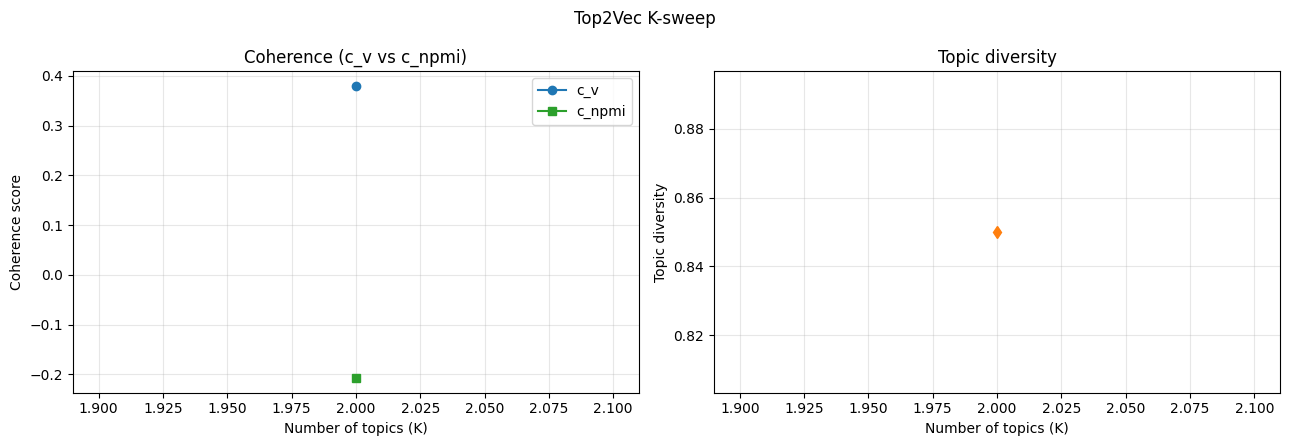


Rekomendasi K (max combined score): 2
Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(sweep_df['K'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (K)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['K'], sweep_df['diversity'], 'd-', color='tab:orange')
ax2.set_xlabel('Number of topics (K)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('Top2Vec K-sweep')
fig.tight_layout()
plt.show()

best_idx = sweep_df['combined'].idxmax()
best_k = int(sweep_df.loc[best_idx, 'K'])
print(f"\nRekomendasi K (max combined score): {best_k}")
print("Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.")

## Final Model

Karena Top2Vec sudah dilatih sekali, tinggal panggil `hierarchical_topic_reduction(NUM_TOPICS)`
sekali lagi dengan K terpilih. Tidak perlu re-train.

In [14]:
NUM_TOPICS = best_k

# Hanya reduce kalau NUM_TOPICS benar-benar lebih kecil dari jumlah topik mentah.
# Kalau sudah sama, hierarchical_topic_reduction akan error -- pakai base topics saja.
USE_REDUCED = NUM_TOPICS < n_topics_raw
if USE_REDUCED:
    base_model.hierarchical_topic_reduction(num_topics=NUM_TOPICS)

# Top words tanpa filter vocab -> ini representasi 'asli' Top2Vec untuk inspeksi kualitatif
top_words_raw = top2vec_top_words(base_model, reduced=USE_REDUCED, topn=15)
# Top words dengan vocab filter -> dipakai untuk metric supaya fair dengan FASTopic/BERTopic
top_words_eval = top2vec_top_words(base_model, reduced=USE_REDUCED, topn=10, vocab_filter=ref_vocab_set)

final_metrics = evaluate_topics(top_words_eval, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal Top2Vec | K={NUM_TOPICS}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words_raw):
    print(f"Topic {i}: {tw}")

top2vec_metrics = {**final_metrics, 'model': 'Top2Vec', 'K': NUM_TOPICS}


Final Top2Vec | K=2  c_v=0.3800  c_npmi=-0.2076  diversity=0.8500

Topic 0: vibecoding vibecode vibecoder vibecoders vibecoded vibes vibe coders flutter codebase coder coded telegram studio codebases
Topic 1: gaming dance music visuals vibecoders vibecoding creativity vibecoded studio art vibecode vibe vibecoder creative vibes


In [15]:
# Topic info table
topic_sizes, topic_nums = base_model.get_topic_sizes(reduced=USE_REDUCED)
topic_info = pd.DataFrame({
    'topic_id': topic_nums,
    'size': topic_sizes,
    'top_words_raw': top_words_raw,
    'top_words_in_shared_vocab': top_words_eval,
})
topic_info.sort_values('size', ascending=False).head(30)

,topic_id,size,top_words_raw,top_words_in_shared_vocab
0,0,18831,vibecoding vibecode vibecoder vibecoders vibec...,vibecoder vibecoders vibes coders flutter code...
1,1,218,gaming dance music visuals vibecoders vibecodi...,gaming dance music visuals vibecoders creativi...



--- Topic 0 ---


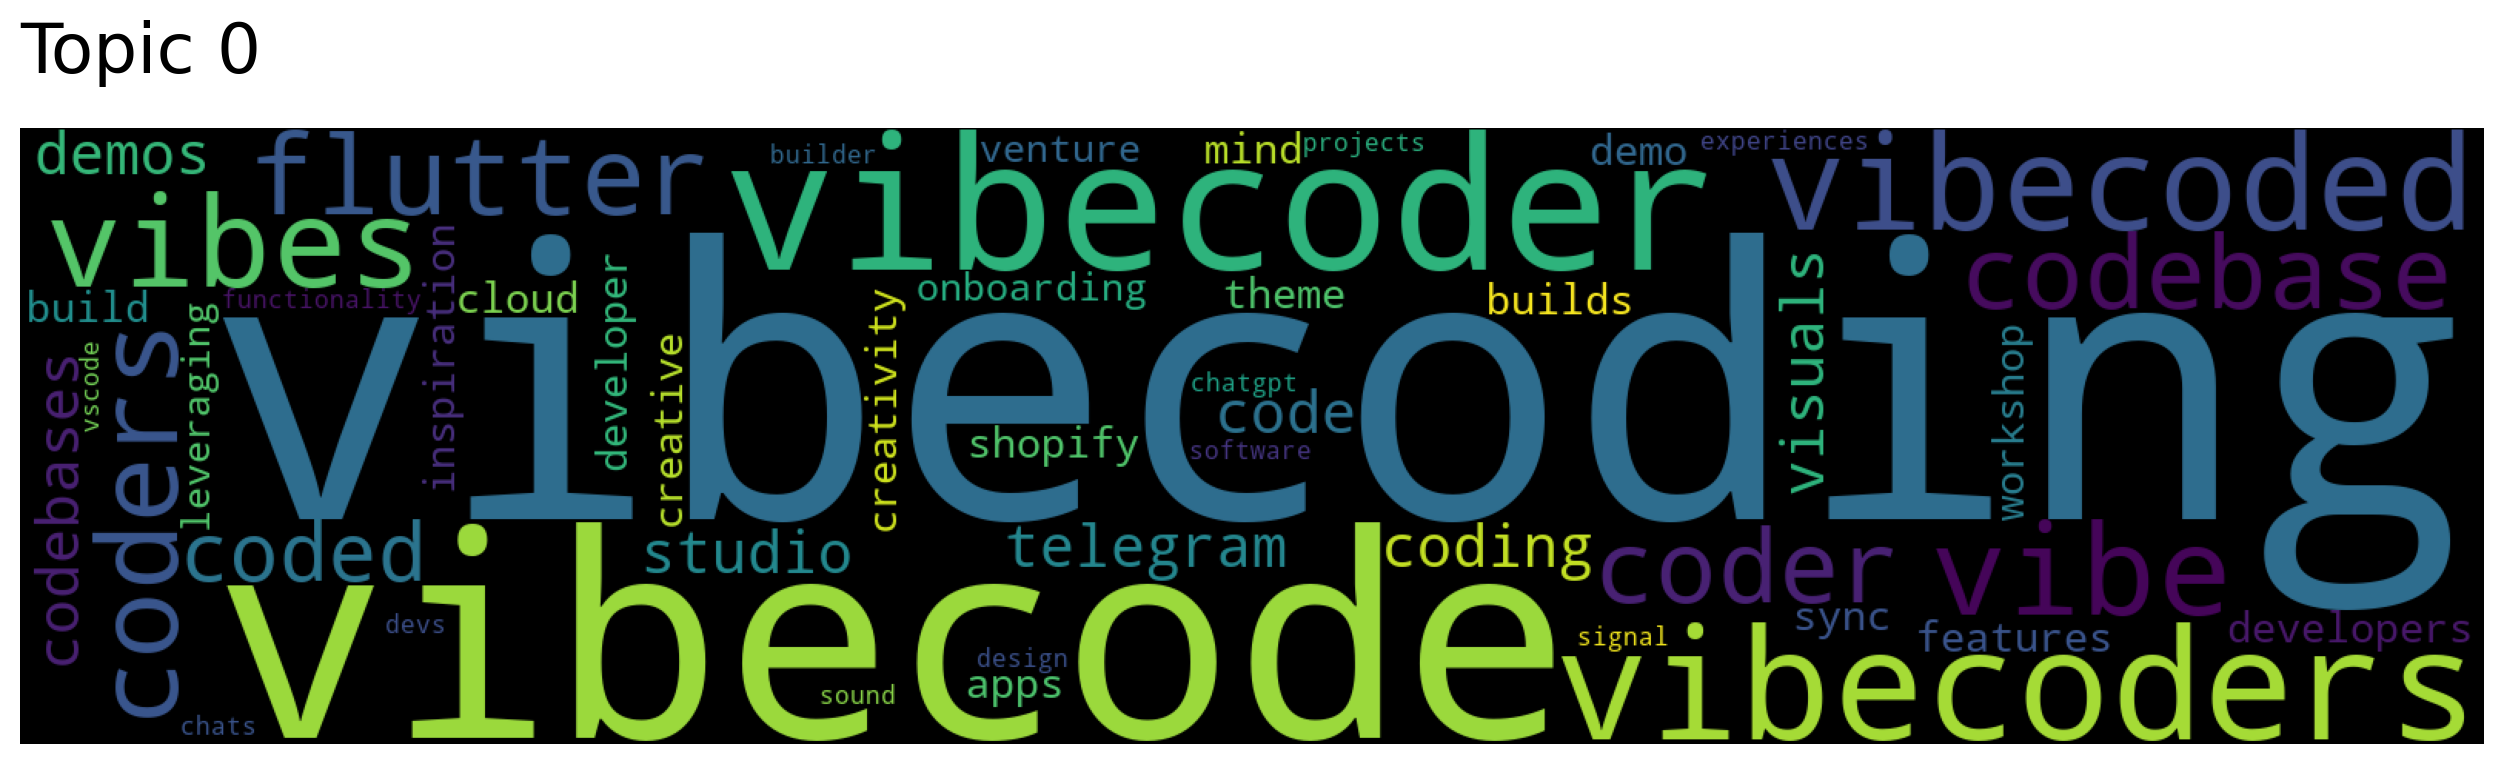


--- Topic 1 ---


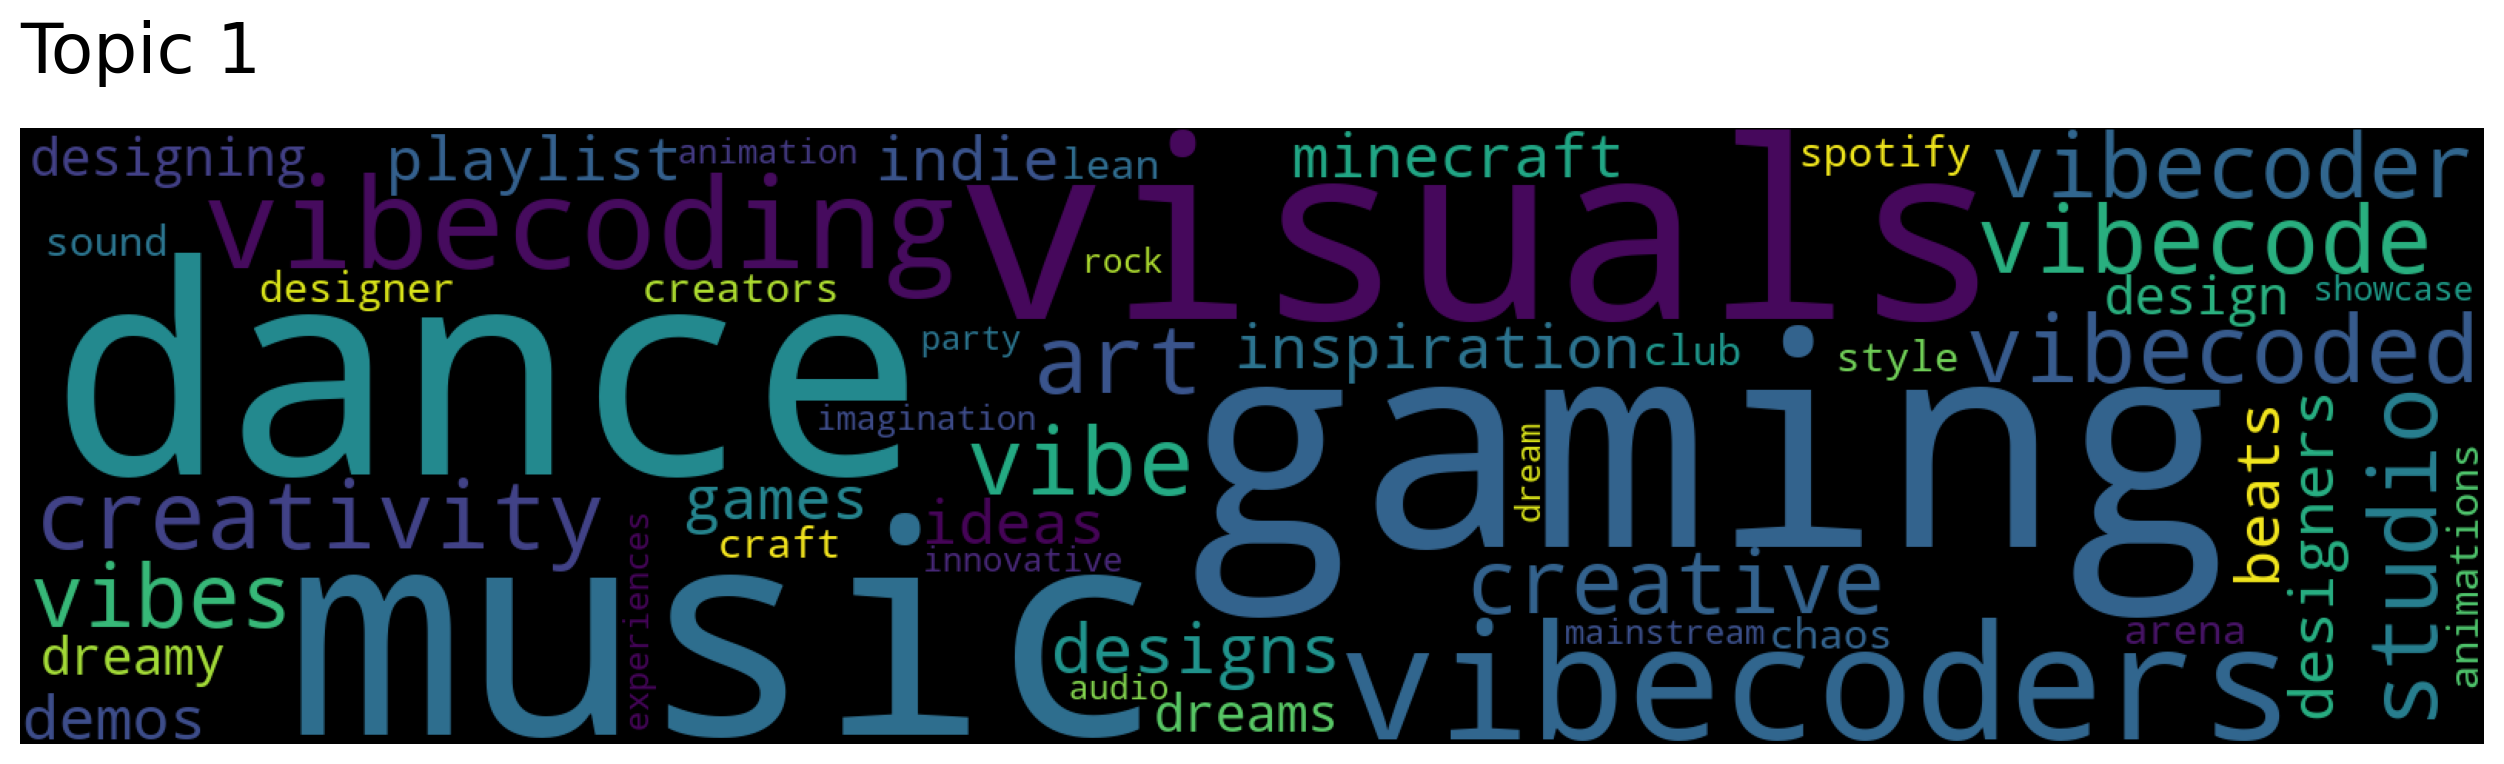

In [16]:
# Word cloud per top topic
import matplotlib.pyplot as plt

top_n_show = min(NUM_TOPICS, 6)
for i in range(top_n_show):
    print(f"\n--- Topic {i} ---")
    base_model.generate_topic_wordcloud(i, reduced=USE_REDUCED)
    plt.show()

In [17]:
# Sample tweets per topic untuk inspeksi kualitatif
def sample_docs_for_topic(topic_id, n=3):
    docs_found, doc_scores, doc_ids = base_model.search_documents_by_topic(
        topic_num=topic_id, num_docs=n, reduced=USE_REDUCED
    )
    return list(docs_found)

for tid in topic_info.sort_values('size', ascending=False)['topic_id'].head(10):
    print(f"\n=== Topic {tid} | top words: {top_words_raw[tid][:120]} ===")
    for s in sample_docs_for_topic(int(tid), n=3):
        print(" -", s[:200])


=== Topic 0 | top words: vibecoding vibecode vibecoder vibecoders vibecoded vibes vibe coders flutter codebase coder coded telegram studio codeba ===
 - devs learn great vibecoding
 - vibecoding project see far
 - vibecoding hype everywhere build app weekend launch chatgpt code automate vibe coded products many live used truth building tools people grit create

=== Topic 1 | top words: gaming dance music visuals vibecoders vibecoding creativity vibecoded studio art vibecode vibe vibecoder creative vibes ===
 - dreamy weirdo dance club consumption music visuals art vibecoding gaming
 - dreamy weirdo dance club consumption music visuals art vibecoding gaming
 - dreamy weirdo dance club consumption music visuals art vibecoding gaming


In [18]:
import os

os.makedirs("artifacts", exist_ok=True)
base_model.save("artifacts/top2vec_vibecoding")

# Document -> topic assignment
doc_topic_ids, doc_topic_scores, _, _ = base_model.get_documents_topics(
    doc_ids=list(range(len(docs))), reduced=USE_REDUCED, num_topics=1
)
assignments = pd.DataFrame({
    "doc": docs,
    "topic_id": doc_topic_ids.flatten() if doc_topic_ids.ndim > 1 else doc_topic_ids,
    "topic_score": doc_topic_scores.flatten() if doc_topic_scores.ndim > 1 else doc_topic_scores,
})
assignments.to_csv("artifacts/top2vec_assignments.csv", index=False)
topic_info.to_csv("artifacts/top2vec_topic_info.csv", index=False)
sweep_df.to_csv("artifacts/top2vec_sweep.csv", index=False)
print("Saved Top2Vec artifacts.")

Saved Top2Vec artifacts.
